# Pertemuan 6: Eksplorasi Data (Exploratory Data Analysis)

**Mata Kuliah:** Pengantar Sains Data  
**Program Studi:** Sains Data  
**Semester:** 2

---

## Tujuan Pembelajaran

Setelah mengikuti pertemuan ini, mahasiswa diharapkan mampu:
1. Menjelaskan definisi dan tujuan Exploratory Data Analysis (EDA)
2. Mengidentifikasi jenis pertanyaan yang dapat dijawab melalui EDA
3. Menginterpretasikan hasil analisis univariat dan bivariat
4. Mendeteksi outlier secara visual menggunakan boxplot dan scatter plot
5. Membaca dan memahami output visualisasi Python (histogram, scatter plot, heatmap korelasi)

---


## 6.1 Definisi dan Tujuan EDA

### Apa itu EDA?

**Exploratory Data Analysis (EDA)** adalah proses **mengenal dan memahami data** sebelum melakukan analisis atau pemodelan lebih lanjut. EDA pertama kali diperkenalkan oleh statistikawan John Tukey pada tahun 1977.

Bayangkan Anda baru saja mendapatkan sebuah buku tebal yang belum pernah Anda baca. Sebelum membaca dari halaman pertama, Anda mungkin akan:
- Melihat sampul dan judul
- Membaca daftar isi
- Membalik beberapa halaman secara acak
- Membaca ringkasan di bagian belakang

**EDA adalah hal yang sama — tetapi untuk data.**

---

### Mengapa EDA Penting?

| Tanpa EDA | Dengan EDA |
|---|---|
| Membangun model dari data yang bermasalah | Mendeteksi masalah data sebelum terlambat |
| Tidak tahu distribusi dan karakteristik data | Memahami pola, tren, dan anomali |
| Mengambil asumsi yang salah | Membuat keputusan analitis yang lebih tepat |
| Hasil model tidak bisa dipercaya | Fondasi analisis yang lebih solid |

---

### Tujuan Utama EDA

1. **Memahami struktur data** — berapa banyak variabel, berapa banyak observasi, tipe data apa saja
2. **Menemukan pola** — apakah ada tren, musiman, atau hubungan antar variabel
3. **Mendeteksi anomali** — outlier, missing values, data yang tidak konsisten
4. **Menguji asumsi** — apakah data memenuhi asumsi yang diperlukan untuk analisis tertentu
5. **Memandu analisis selanjutnya** — menentukan metode yang paling sesuai


## 6.2 Jenis Pertanyaan yang Dijawab EDA

EDA membantu menjawab dua kelompok pertanyaan besar:

### Pertanyaan tentang Satu Variabel (Univariat)
- Bagaimana distribusi nilai variabel ini?
- Berapa nilai rata-rata, median, dan modusnya?
- Apakah ada nilai yang sangat ekstrem (outlier)?
- Apakah distribusinya simetris atau condong ke satu sisi?

### Pertanyaan tentang Hubungan Antar Variabel (Bivariat/Multivariat)
- Apakah variabel A dan variabel B berkorelasi?
- Jika A naik, apakah B cenderung naik atau turun?
- Apakah ada kelompok/cluster yang terbentuk?
- Variabel mana yang paling mempengaruhi variabel target?

### Pertanyaan tentang Kualitas Data
- Apakah ada missing values?
- Apakah ada data duplikat?
- Apakah format data sudah konsisten?
- Apakah ada nilai yang tidak masuk akal?

---

> **Catatan untuk Dosen:** Minta mahasiswa untuk memikirkan satu contoh dataset dari kehidupan sehari-hari (misalnya: nilai ujian, harga makanan, data cuaca) dan pertanyaan apa yang ingin mereka jawab dari dataset tersebut.


## Persiapan: Memuat Dataset

Pada pertemuan ini kita akan menggunakan **dataset Iris** — salah satu dataset paling ikonik dalam dunia sains data, yang berisi pengukuran fisik dari tiga spesies bunga Iris.

### Tentang Dataset Iris

| Variabel | Tipe | Keterangan |
|---|---|---|
| `sepal_length` | Numerik (cm) | Panjang kelopak luar bunga |
| `sepal_width` | Numerik (cm) | Lebar kelopak luar bunga |
| `petal_length` | Numerik (cm) | Panjang kelopak dalam bunga |
| `petal_width` | Numerik (cm) | Lebar kelopak dalam bunga |
| `species` | Kategorikal | Spesies bunga: setosa, versicolor, virginica |

Dataset ini terdiri dari **150 observasi** dengan **3 spesies** yang masing-masing memiliki 50 sampel.


In [14]:
# ============================================================
# PERSIAPAN: Import library dan memuat dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Pengaturan tampilan
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

# Memuat dataset Iris dari sklearn (built-in, tidak butuh koneksi internet)
iris = load_iris()
df = pd.DataFrame(
    iris.data,
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset berhasil dimuat!")
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"Nama kolom     : {list(df.columns)}")


Dataset berhasil dimuat!
Jumlah baris   : 150
Jumlah kolom   : 5
Nama kolom     : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [15]:
# Melihat 5 baris pertama dataset
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
# Melihat informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


> **Diskusi Kelas:** Dari output `df.info()` di atas, apa yang bisa kita ketahui tentang dataset ini? Perhatikan tipe data setiap kolom dan apakah ada missing values.

In [17]:
# Statistik deskriptif dasar
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


> **Diskusi Kelas:** Perhatikan output `df.describe()`. Kolom mana yang memiliki rentang nilai (max - min) paling besar? Apa artinya secara praktis?

---

## 6.3 Analisis Univariat: Distribusi Satu Variabel

**Analisis univariat** adalah analisis yang berfokus pada **satu variabel saja**. Tujuannya adalah memahami karakteristik dan distribusi variabel tersebut.

### Pertanyaan yang dijawab:
- Di sekitar nilai berapa data paling banyak berkumpul?
- Seberapa menyebar nilai-nilai data?
- Apakah distribusinya simetris atau condong ke satu sisi (skewed)?
- Apakah ada nilai yang sangat berbeda dari yang lain?

### Alat visualisasi utama:
- **Histogram** — menampilkan frekuensi distribusi nilai
- **Boxplot** — menampilkan ringkasan distribusi dan outlier
- **KDE Plot** — kurva kepadatan distribusi yang lebih halus


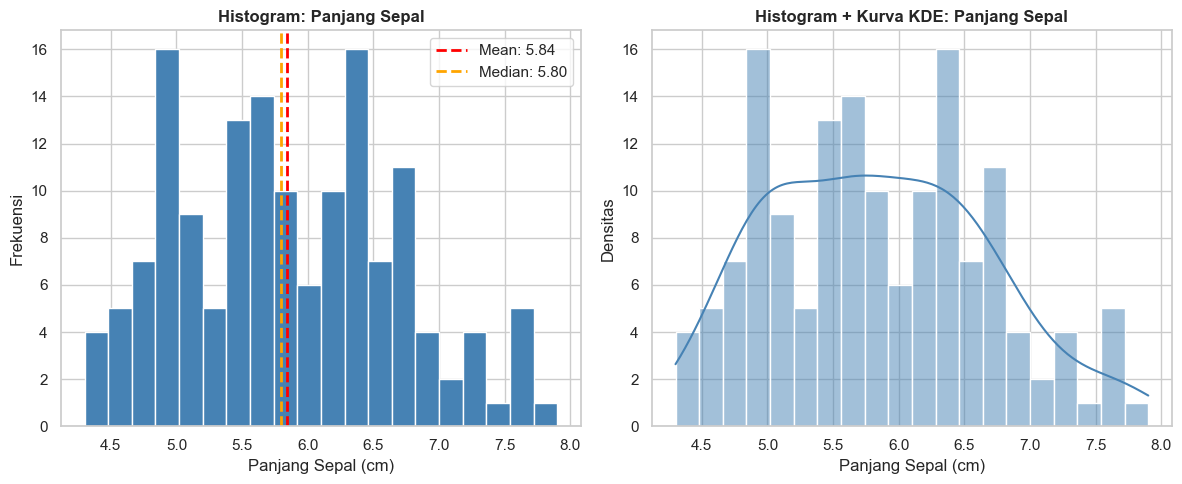


Statistik sepal_length:
  Mean   : 5.84 cm
  Median : 5.80 cm
  Std Dev: 0.83 cm


In [18]:
# ============================================================
# HISTOGRAM: Distribusi panjang kelopak (sepal_length)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram sederhana
axes[0].hist(df['sepal_length'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram: Panjang Sepal', fontweight='bold')
axes[0].set_xlabel('Panjang Sepal (cm)')
axes[0].set_ylabel('Frekuensi')

# Tambahkan garis mean dan median
mean_val = df['sepal_length'].mean()
median_val = df['sepal_length'].median()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
axes[0].legend()

# Histogram dengan kurva distribusi (KDE)
sns.histplot(df['sepal_length'], bins=20, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Histogram + Kurva KDE: Panjang Sepal', fontweight='bold')
axes[1].set_xlabel('Panjang Sepal (cm)')
axes[1].set_ylabel('Densitas')

plt.tight_layout()
plt.show()

print(f"\nStatistik sepal_length:")
print(f"  Mean   : {mean_val:.2f} cm")
print(f"  Median : {median_val:.2f} cm")
print(f"  Std Dev: {df['sepal_length'].std():.2f} cm")

> **Cara Membaca Histogram:**
> - **Sumbu X** = nilai variabel (panjang sepal dalam cm)
> - **Sumbu Y** = berapa banyak data yang jatuh pada rentang nilai tersebut
> - **Batang tinggi** = nilai tersebut sering muncul
> - **Garis merah (mean)** vs **garis orange (median)**: jika keduanya berdekatan, distribusi cenderung simetris
>
> **Diskusi Kelas:** Apakah distribusi sepal_length terlihat simetris? Mean dan median berada di posisi yang hampir sama — apa artinya?

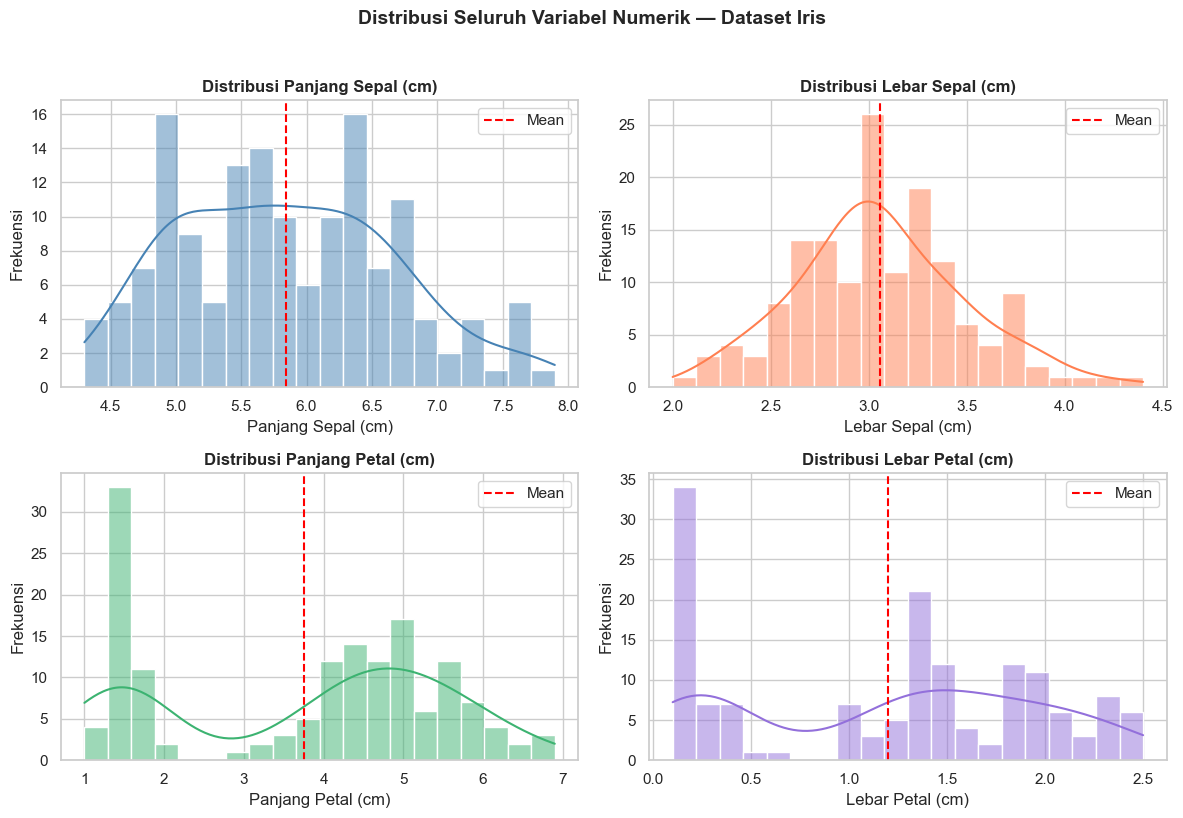

In [19]:
# ============================================================
# HISTOGRAM: Semua variabel numerik sekaligus
# ============================================================

variabel_numerik = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
label_variabel = ['Panjang Sepal (cm)', 'Lebar Sepal (cm)', 'Panjang Petal (cm)', 'Lebar Petal (cm)']
warna = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (var, label, warna_) in enumerate(zip(variabel_numerik, label_variabel, warna)):
    sns.histplot(df[var], bins=20, kde=True, color=warna_, ax=axes[i])
    axes[i].set_title(f'Distribusi {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].legend()

plt.suptitle('Distribusi Seluruh Variabel Numerik — Dataset Iris', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Diskusi Kelas:** Perhatikan perbedaan bentuk distribusi antar variabel:
> - `sepal_length` dan `sepal_width` → distribusi mendekati normal (lonceng)
> - `petal_length` dan `petal_width` → distribusi **bimodal** (dua puncak)
>
> Apa yang kira-kira menyebabkan distribusi petal terlihat seperti itu? *(Petunjuk: ingat bahwa ada 3 spesies bunga dalam dataset ini)*

---

## 6.4 Analisis Bivariat: Hubungan Antar Dua Variabel

**Analisis bivariat** melihat **hubungan antara dua variabel** secara bersamaan. Ini membantu kita memahami apakah perubahan pada satu variabel berhubungan dengan perubahan pada variabel lain.

### Jenis Hubungan yang Bisa Ditemukan:

| Jenis Hubungan | Deskripsi | Contoh |
|---|---|---|
| **Korelasi positif** | Jika A naik, B cenderung naik | Tinggi badan dan berat badan |
| **Korelasi negatif** | Jika A naik, B cenderung turun | Suhu dan penjualan jaket |
| **Tidak berkorelasi** | A dan B tidak saling mempengaruhi | Ukuran sepatu dan nilai ujian |

### Alat visualisasi utama:
- **Scatter plot** — menampilkan hubungan dua variabel numerik
- **Heatmap korelasi** — menampilkan kekuatan korelasi semua pasang variabel sekaligus
- **Boxplot per kelompok** — membandingkan distribusi satu variabel antar kelompok


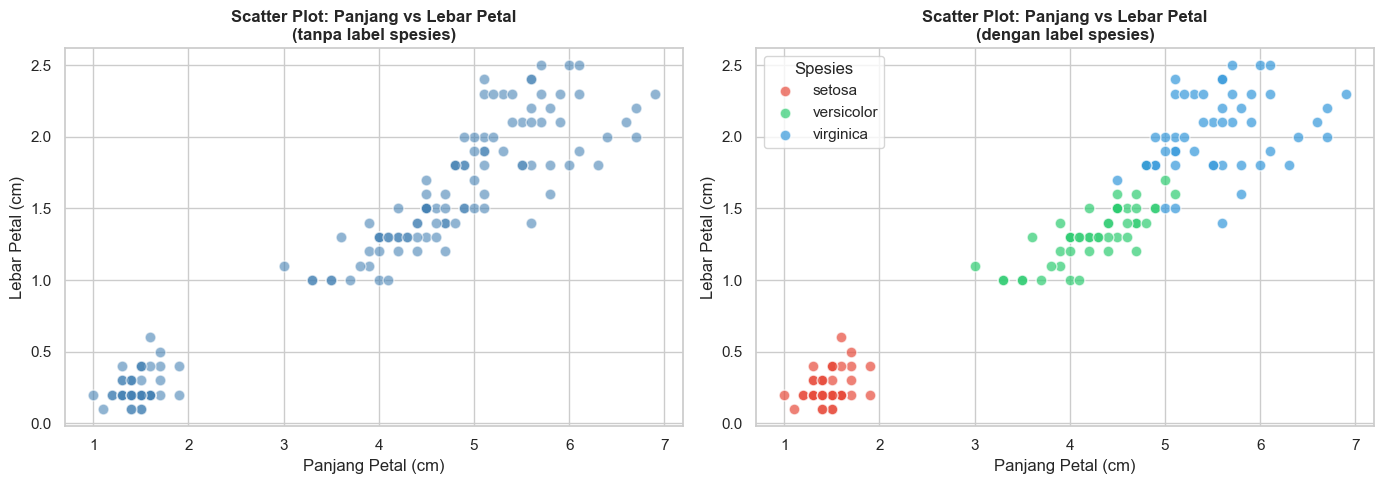

In [20]:
# ============================================================
# SCATTER PLOT: Hubungan antara panjang dan lebar petal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot sederhana (tanpa informasi spesies)
axes[0].scatter(df['petal_length'], df['petal_width'], 
                color='steelblue', alpha=0.6, edgecolors='white', s=60)
axes[0].set_title('Scatter Plot: Panjang vs Lebar Petal\n(tanpa label spesies)', fontweight='bold')
axes[0].set_xlabel('Panjang Petal (cm)')
axes[0].set_ylabel('Lebar Petal (cm)')

# Scatter plot dengan warna per spesies
warna_spesies = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
for spesies, warna_ in warna_spesies.items():
    subset = df[df['species'] == spesies]
    axes[1].scatter(subset['petal_length'], subset['petal_width'],
                   label=spesies, color=warna_, alpha=0.7, edgecolors='white', s=60)

axes[1].set_title('Scatter Plot: Panjang vs Lebar Petal\n(dengan label spesies)', fontweight='bold')
axes[1].set_xlabel('Panjang Petal (cm)')
axes[1].set_ylabel('Lebar Petal (cm)')
axes[1].legend(title='Spesies')

plt.tight_layout()
plt.show()

> **Cara Membaca Scatter Plot:**
> - Setiap **titik** mewakili satu observasi (satu bunga)
> - **Sumbu X** = nilai variabel pertama (panjang petal)
> - **Sumbu Y** = nilai variabel kedua (lebar petal)
> - Jika titik-titik membentuk **pola diagonal naik** → korelasi positif
> - Jika titik-titik **tersebar acak** → tidak ada korelasi
>
> **Diskusi Kelas:** 
> - Grafik kiri vs kanan — apa perbedaan informasi yang bisa kita peroleh?
> - Spesies mana yang paling mudah dipisahkan dari dua spesies lainnya?

In [21]:
# ============================================================
# HEATMAP KORELASI: Melihat korelasi semua pasang variabel
# ============================================================

# Hitung matriks korelasi
korelasi = df[variabel_numerik].corr()

print("Matriks Korelasi:")
print(korelasi.round(2))

Matriks Korelasi:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00


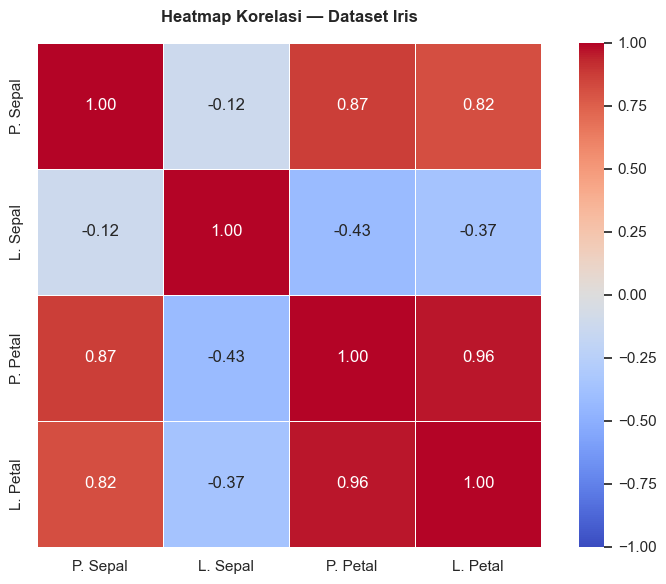

In [22]:
# Visualisasikan sebagai heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    korelasi,
    annot=True,          # Tampilkan angka korelasi
    fmt='.2f',           # Format 2 desimal
    cmap='coolwarm',     # Skema warna: merah = positif, biru = negatif
    vmin=-1, vmax=1,     # Skala dari -1 hingga 1
    square=True,
    linewidths=0.5,
    xticklabels=['P. Sepal', 'L. Sepal', 'P. Petal', 'L. Petal'],
    yticklabels=['P. Sepal', 'L. Sepal', 'P. Petal', 'L. Petal']
)
plt.title('Heatmap Korelasi — Dataset Iris', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

> **Cara Membaca Heatmap Korelasi:**
> 
> Nilai korelasi (r) berkisar antara **-1 hingga +1**:
> 
> | Nilai r | Interpretasi |
> |---|---|
> | r = 1.00 | Korelasi positif sempurna |
> | 0.70 ≤ r < 1.00 | Korelasi positif kuat |
> | 0.40 ≤ r < 0.70 | Korelasi positif sedang |
> | 0.00 ≤ r < 0.40 | Korelasi positif lemah |
> | r = 0.00 | Tidak ada korelasi |
> | -0.40 < r ≤ 0.00 | Korelasi negatif lemah |
> | -0.70 < r ≤ -0.40 | Korelasi negatif sedang |
> | -1.00 < r ≤ -0.70 | Korelasi negatif kuat |
> | r = -1.00 | Korelasi negatif sempurna |
> 
> - **Warna merah** = korelasi positif (semakin merah, semakin kuat)
> - **Warna biru** = korelasi negatif (semakin biru, semakin kuat)
> - **Diagonal utama** selalu bernilai 1.00 (variabel berkorelasi sempurna dengan dirinya sendiri)
> 
> **Diskusi Kelas:**
> - Pasang variabel mana yang memiliki korelasi paling kuat?
> - Pasang variabel mana yang berkorelasi negatif?
> - Mengapa korelasi antara petal_length dan petal_width sangat tinggi?

---

## 6.5 Deteksi Outlier Secara Visual

**Outlier** adalah nilai yang **sangat berbeda** dari sebagian besar data. Outlier bisa terjadi karena:
- Kesalahan pencatatan data (human error)
- Kesalahan pengukuran (alat rusak)
- Kejadian yang memang benar-benar ekstrem (gempa bumi, krisis ekonomi)

### Mengapa Outlier Penting?
Outlier dapat **mendistorsi hasil analisis** — misalnya, satu nilai yang sangat besar bisa membuat rata-rata menjadi jauh lebih tinggi dari nilai yang sebenarnya representatif.

### Alat Deteksi Visual:
- **Boxplot** — cara paling umum dan efisien untuk mendeteksi outlier
- **Scatter plot** — mendeteksi outlier dalam konteks dua variabel


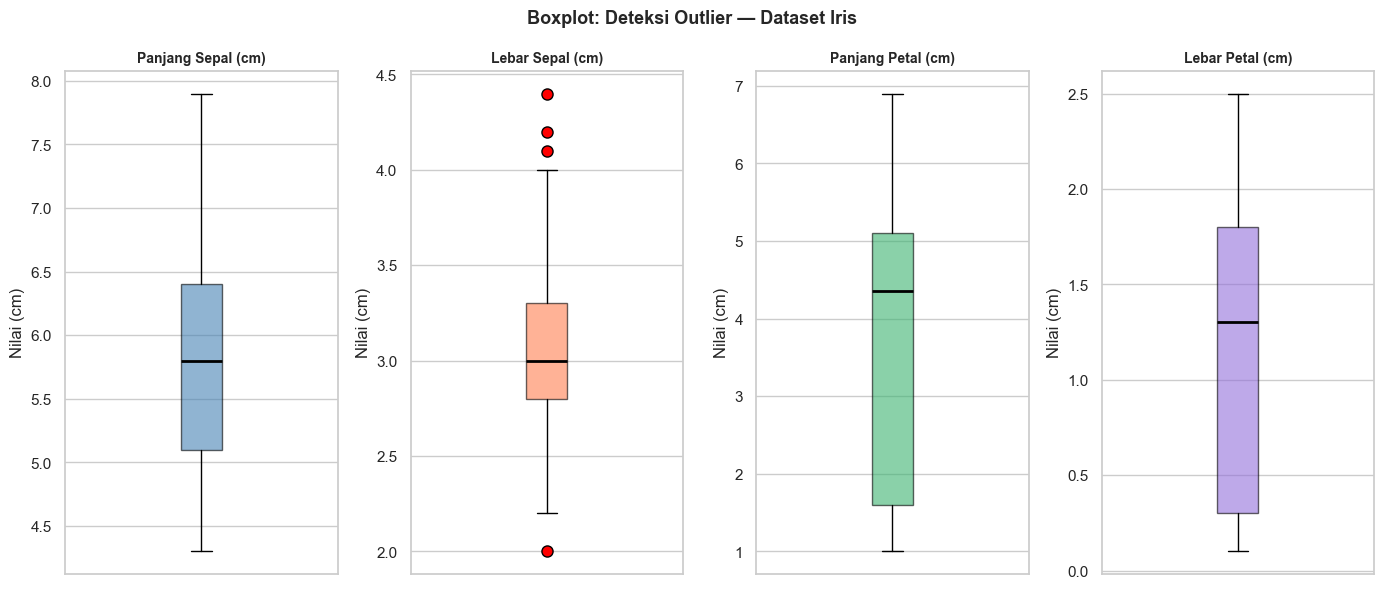

In [23]:
# ============================================================
# BOXPLOT: Mendeteksi outlier pada semua variabel numerik
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(14, 6))

for i, (var, label, warna_) in enumerate(zip(variabel_numerik, label_variabel, warna)):
    axes[i].boxplot(df[var], patch_artist=True,
                   boxprops=dict(facecolor=warna_, alpha=0.6),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='red', 
                                  markersize=8, label='Outlier'))
    axes[i].set_title(label, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Nilai (cm)')
    axes[i].set_xticks([])

plt.suptitle('Boxplot: Deteksi Outlier — Dataset Iris', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Cara Membaca Boxplot:**
> 
> ```
>    ───  ← Nilai maksimum (batas atas whisker)
>     │
>    ┌─┐  ← Q3 (kuartil ketiga / 75%)
>    │─│  ← Median (Q2 / 50%)
>    └─┘  ← Q1 (kuartil pertama / 25%)
>     │
>    ───  ← Nilai minimum (batas bawah whisker)
>     ○   ← OUTLIER (titik di luar whisker)
> ```
> 
> - **Kotak (box)** = rentang nilai 50% data di tengah (IQR = Q3 - Q1)
> - **Garis tebal di dalam kotak** = median
> - **Garis vertikal (whisker)** = rentang nilai yang masih dianggap normal (1.5 × IQR)
> - **Titik di luar whisker** = outlier
> 
> **Diskusi Kelas:** Variabel mana yang memiliki outlier? Apakah outlier tersebut perlu dihapus atau ditangani dengan cara lain?

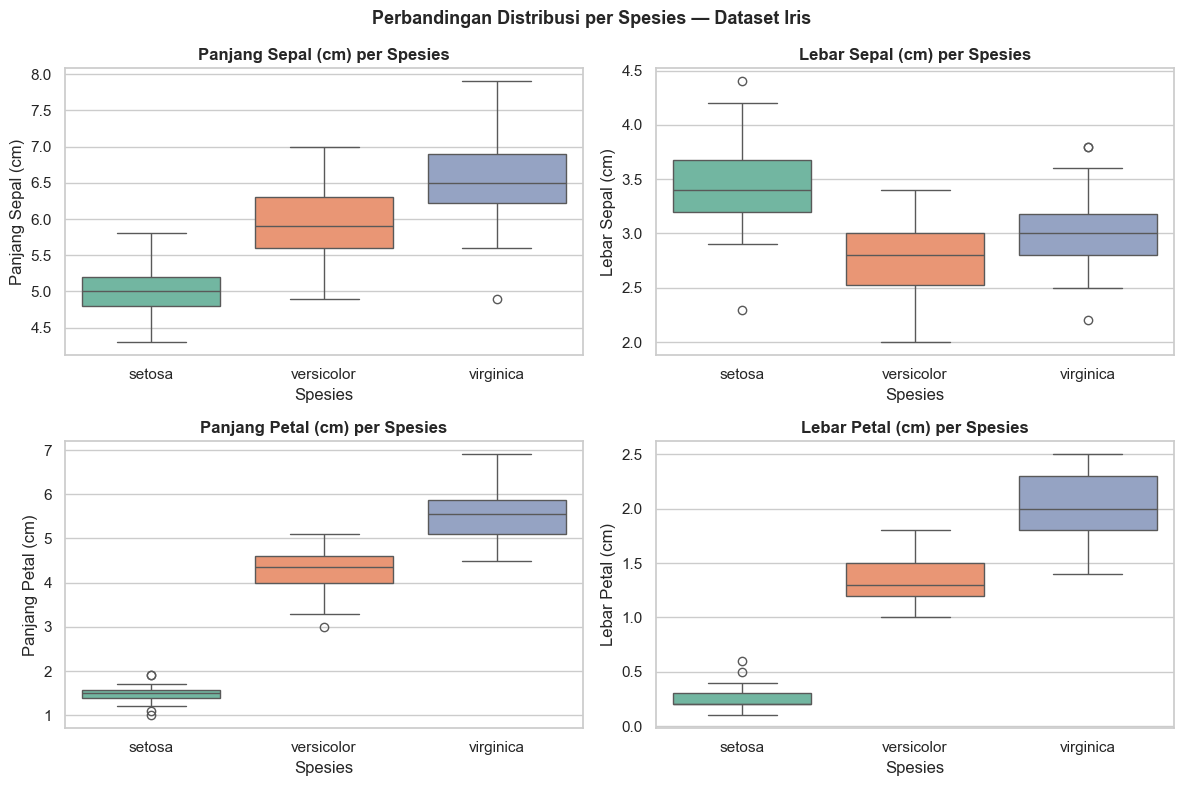

In [24]:
# ============================================================
# BOXPLOT PER SPESIES: Perbandingan distribusi antar kelompok
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (var, label) in enumerate(zip(variabel_numerik, label_variabel)):
    sns.boxplot(data=df, x='species', y=var,
               hue='species', palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'{label} per Spesies', fontweight='bold')
    axes[i].set_xlabel('Spesies')
    axes[i].set_ylabel(label)

plt.suptitle('Perbandingan Distribusi per Spesies — Dataset Iris',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **Diskusi Kelas:**
> - Variabel mana yang paling jelas **membedakan** ketiga spesies?
> - Spesies mana yang memiliki variasi nilai paling kecil (kotak paling kecil)?
> - Jika Anda hanya boleh memilih **satu variabel** untuk membedakan spesies Iris, variabel mana yang Anda pilih?

---

## 6.6 Ilustrasi Python: Menggabungkan Semuanya

Pada bagian ini, kita akan melihat bagaimana EDA lengkap dilakukan dalam satu alur kerja yang terintegrasi — dari memuat data hingga visualisasi komprehensif.


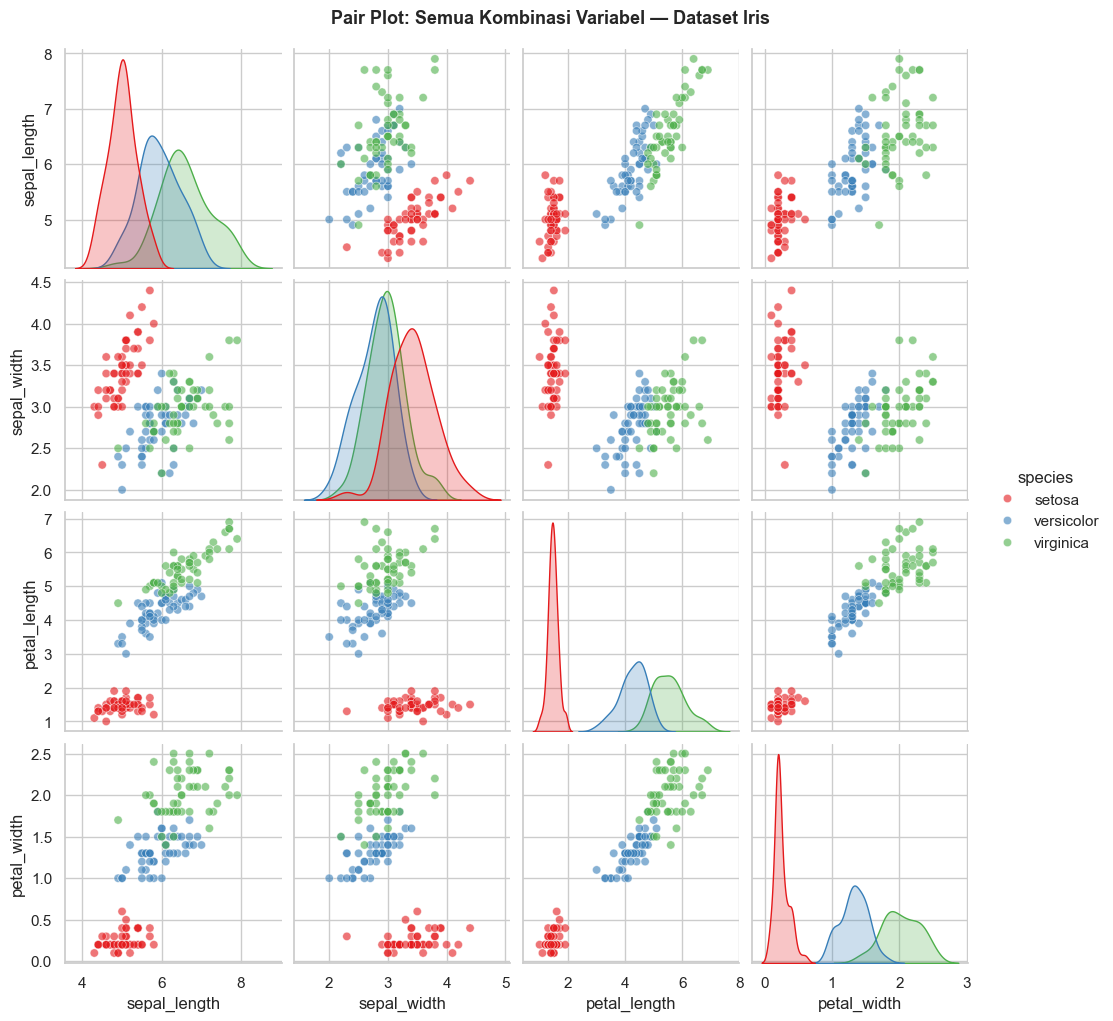

In [25]:
# ============================================================
# PAIR PLOT: Visualisasi komprehensif semua kombinasi variabel
# ============================================================

g = sns.pairplot(
    df, 
    hue='species',           # Warnai titik berdasarkan spesies
    palette='Set1',
    diag_kind='kde',         # Diagonal: kurva KDE
    plot_kws={'alpha': 0.6}
)
g.fig.suptitle('Pair Plot: Semua Kombinasi Variabel — Dataset Iris', 
               fontsize=13, fontweight='bold', y=1.02)
plt.show()

> **Cara Membaca Pair Plot:**
> - **Diagonal** = distribusi setiap variabel (dalam bentuk KDE)
> - **Di luar diagonal** = scatter plot untuk setiap pasang variabel
> - **Warna** = menandakan spesies yang berbeda
> - Pair plot sangat berguna untuk melihat **semua hubungan antar variabel sekaligus** dalam satu tampilan


In [26]:
# ============================================================
# RINGKASAN EDA: Cetak temuan utama secara otomatis
# ============================================================

print("=" * 55)
print("        RINGKASAN EDA — DATASET IRIS")
print("=" * 55)

print(f"\n Ukuran Dataset  : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f" Jumlah Spesies  : {df['species'].nunique()} ({', '.join(df['species'].unique())})")
print(f" Missing Values  : {df.isnull().sum().sum()} (tidak ada missing values)")

print("\n Korelasi Tertinggi:")
korelasi_upper = korelasi.where(
    np.triu(np.ones(korelasi.shape), k=1).astype(bool)
)
top_korelasi = korelasi_upper.stack().sort_values(ascending=False)
for (var1, var2), nilai in top_korelasi.head(3).items():
    print(f"   {var1} ↔ {var2}: r = {nilai:.2f}")

print("\n Deteksi Outlier (metode IQR):")
for var in variabel_numerik:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    n_outlier = ((df[var] < batas_bawah) | (df[var] > batas_atas)).sum()
    print(f"   {var:20s}: {n_outlier} outlier")

print("\n" + "=" * 55)

        RINGKASAN EDA — DATASET IRIS

 Ukuran Dataset  : 150 baris × 5 kolom
 Jumlah Spesies  : 3 (setosa, versicolor, virginica)
 Missing Values  : 0 (tidak ada missing values)

 Korelasi Tertinggi:
   petal_length ↔ petal_width: r = 0.96
   sepal_length ↔ petal_length: r = 0.87
   sepal_length ↔ petal_width: r = 0.82

 Deteksi Outlier (metode IQR):
   sepal_length        : 0 outlier
   sepal_width         : 4 outlier
   petal_length        : 0 outlier
   petal_width         : 0 outlier



> **Diskusi Penutup:**
> Berdasarkan seluruh proses EDA yang telah kita lakukan, jawablah pertanyaan berikut:
> 1. Variabel apa yang paling informatif untuk membedakan spesies Iris?
> 2. Apakah dataset ini cukup bersih untuk langsung dianalisis lebih lanjut?
> 3. Jika Anda ingin membangun model klasifikasi spesies, fitur mana yang akan Anda prioritaskan?

---

## Ringkasan Pertemuan

| Konsep | Poin Kunci |
|---|---|
| **EDA** | Proses mengenal data sebelum analisis lebih lanjut |
| **Analisis Univariat** | Memahami distribusi satu variabel (histogram, boxplot) |
| **Analisis Bivariat** | Memahami hubungan dua variabel (scatter plot, heatmap) |
| **Outlier** | Nilai ekstrem yang perlu diidentifikasi sebelum pemodelan |
| **Korelasi** | Ukuran kekuatan hubungan linier antar dua variabel (−1 hingga +1) |

---

## Tugas Mandiri (Asinkronus)

Pilih **satu dataset publik** dari [Kaggle](https://www.kaggle.com/datasets) atau [BPS](https://www.bps.go.id) yang menarik bagi Anda. Kemudian:
1. Identifikasi variabel-variabel yang ada beserta tipenya
2. Tuliskan minimal **3 pertanyaan** yang ingin Anda jawab dari dataset tersebut
3. Identifikasi potensi masalah kualitas data yang mungkin ada
4. Dokumentasikan temuan Anda dalam format laporan singkat (1–2 halaman)

>  Estimasi waktu pengerjaan: **±3 jam**
